In [20]:
# IMPORT ALL PROJECT MODULES

from ball_observation import BallObservation
from ball_trajectory import Ball, simulate_n_balls
from particle_filter import ParticleFilter
from nball_particle_filter import NBallParticleFilter
import importlib
import plotting
importlib.reload(plotting)

from plotting import (
    BallTrajectoryPlot,
    BallObservationPlot,
    ParticleFilterTrajectoryPlot,
    nBallTrajectoryPlot,
    BallCountPlot,
    TrackingErrorPlot,
    extract_dropout_regions,
    compute_tracking_errors
)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation



TIME STEP|| TRAJECTORY(x,y)1:
------------------------------
t= 0.00s || (  0.00,   0.00)
t= 0.10s || (  5.73,   3.92)
t= 0.20s || ( 11.47,   7.74)
t= 0.30s || ( 17.20,  11.46)
t= 0.40s || ( 22.94,  15.08)
t= 0.50s || ( 28.67,  18.60)
t= 0.60s || ( 34.40,  22.03)
t= 0.70s || ( 40.14,  25.36)
t= 0.80s || ( 45.87,  28.59)
t= 0.90s || ( 51.61,  31.72)
t= 1.00s || ( 57.34,  34.75)
t= 1.10s || ( 63.07,  37.69)
t= 1.20s || ( 68.81,  40.53)
t= 1.30s || ( 74.54,  43.27)
t= 1.40s || ( 80.28,  45.91)
t= 1.50s || ( 86.01,  48.45)
t= 1.60s || ( 91.75,  50.90)
t= 1.70s || ( 97.48,  53.25)
t= 1.80s || (103.21,  55.50)
t= 1.90s || (108.95,  57.65)
t= 2.00s || (114.68,  59.70)
t= 2.10s || (120.42,  61.65)
t= 2.20s || (126.15,  63.51)
t= 2.30s || (131.88,  65.27)
t= 2.40s || (137.62,  66.93)
t= 2.50s || (143.35,  68.49)
t= 2.60s || (149.09,  69.96)
t= 2.70s || (154.82,  71.32)
t= 2.80s || (160.55,  72.59)
t= 2.90s || (166.29,  73.76)
t= 3.00s || (172.02,  74.83)
t= 3.10s || (177.76,  75.81)
t= 3.20s |

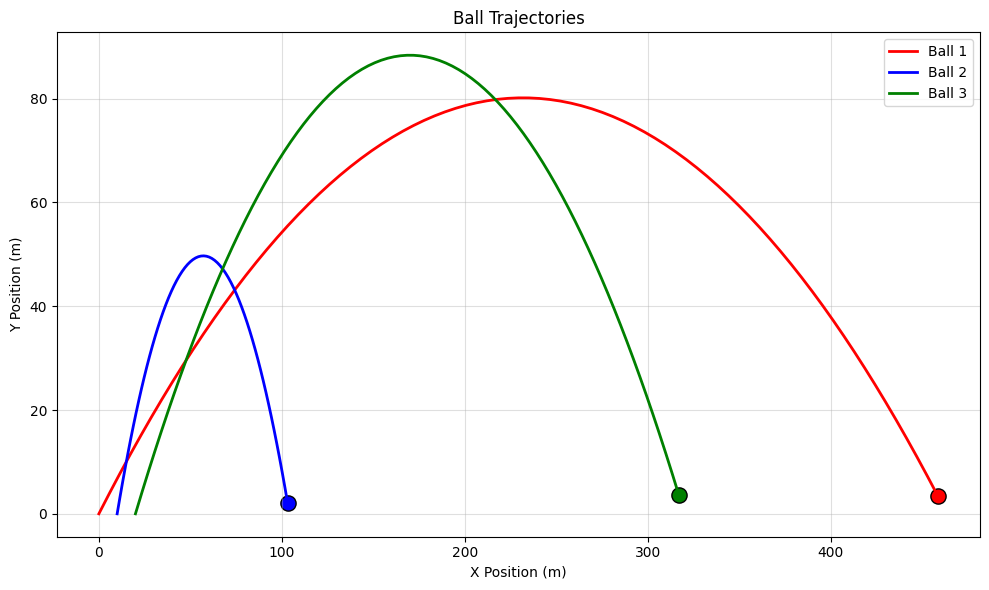

In [21]:

SAMPLE_SETS = {
        1: [  # Different angles, wide separation 
            {"initial_position": [0,  0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [20, 0], "speed": 60, "angle_degrees": 30},
        ],
        2: [  # Steep vs shallow 
            {"initial_position": [0,  0], "speed": 55, "angle_degrees": 75},
            {"initial_position": [15, 0], "speed": 45, "angle_degrees": 25},
        ],
        3: [  # Similar speeds and angles 
            {"initial_position": [0, 0], "speed": 50, "angle_degrees": 45},
            {"initial_position": [5, 0], "speed": 52, "angle_degrees": 47},
        ],
        4: [  # Fast vs slow, different heights
            {"initial_position": [0,  0], "speed": 70, "angle_degrees": 35},
            {"initial_position": [10, 0], "speed": 35, "angle_degrees": 65},
            {"initial_position": [20, 0], "speed": 55, "angle_degrees": 50},
        ],
    }

SAMPLE = 4      
launches = SAMPLE_SETS[SAMPLE]
DT           = 0.1


trajectories = simulate_n_balls(launches, dt=DT)
for i, traj in enumerate(trajectories):
    print(f"\nTIME STEP|| TRAJECTORY(x,y){i+1}:")
    print("------------------------------")
    for t, x, y in traj:
        print(f"t={t:5.2f}s || ({x:6.2f}, {y:6.2f})")
# Visualize trajectory
plotter = BallTrajectoryPlot(launches)
plotter.visualize()

TIME STEP || BALL 1 ||
           || Obs. (x,y) ||
---------------------------------------------------------------

Ball 1:
t= 0.00s || ( -4.89,   1.61)
t= 0.10s || Observation Dropped
t= 0.20s || (  6.54,   5.86)
t= 0.30s || ( 23.16,  12.46)
t= 0.40s || ( 23.19,  10.62)
t= 0.50s || ( 32.49,  22.25)
t= 0.60s || ( 30.56,  21.71)
t= 0.70s || ( 44.90,  25.33)
t= 0.80s || Observation Dropped
t= 0.90s || Observation Dropped
t= 1.00s || ( 57.45,  37.15)
t= 1.10s || Observation Dropped
t= 1.20s || ( 75.70,  39.23)
t= 1.30s || ( 72.95,  40.52)
t= 1.40s || ( 82.04,  43.92)
t= 1.50s || ( 88.26,  52.37)
t= 1.60s || ( 92.33,  43.07)
t= 1.70s || (101.80,  50.18)
t= 1.80s || (103.40,  58.60)
t= 1.90s || Observation Dropped
t= 2.00s || (119.78,  54.85)
t= 2.10s || (118.87,  60.96)
t= 2.20s || (126.38,  65.43)
t= 2.30s || (130.48,  67.45)
t= 2.40s || (138.92,  69.69)
t= 2.50s || (139.34,  71.97)
t= 2.60s || (151.53,  71.21)
t= 2.70s || (148.02,  69.11)
t= 2.80s || (155.88,  73.32)
t= 2.90s || (170.20,

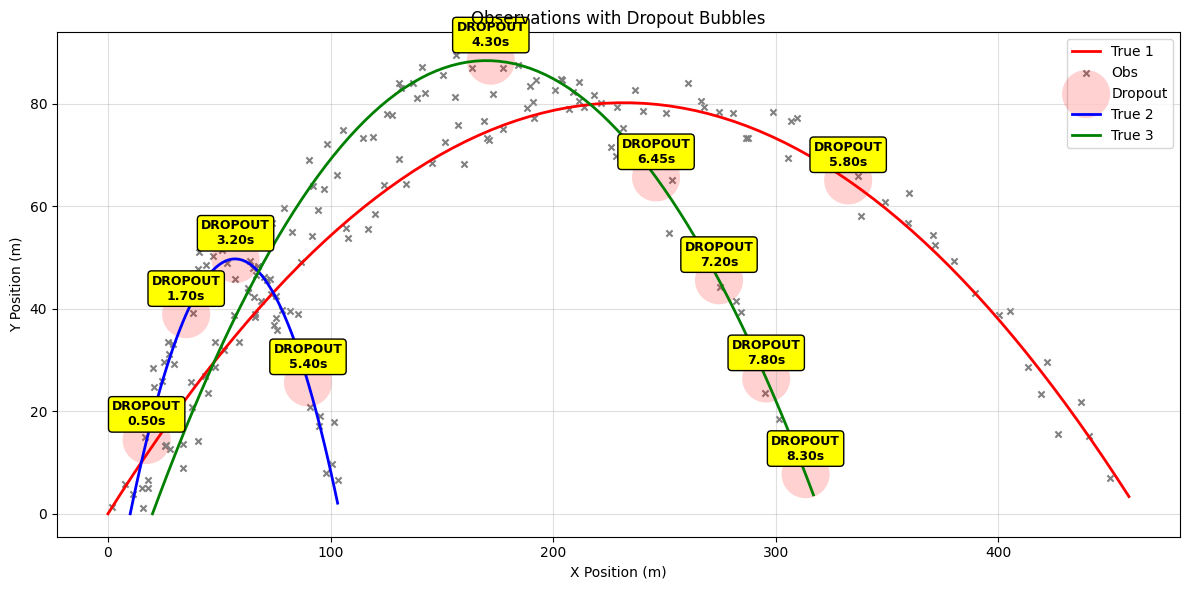

In [27]:
#BallObservation

NOISE_STDDEV = 3.0
DROPOUT_PROB = 0.15
observers     = [BallObservation(traj, noise_stddev=NOISE_STDDEV, dropout_prob=DROPOUT_PROB)
                     for traj in trajectories]
obs_sequences = [obs.simulate_observations() for obs in observers]
print("===============================================================")
print("TIME STEP || BALL 1 ||")
print("           || Obs. (x,y) ||")
print("---------------------------------------------------------------")

for i, obs in enumerate(observers):
    print(f"\nBall {i + 1}:")
    observations = obs.simulate_observations()
    for t, position in observations:
        if position is not None:
            print(f"t={t:5.2f}s || ({position[0]:6.2f}, {position[1]:6.2f})")
        else:
            print(f"t={t:5.2f}s || Observation Dropped")
    
plotter = BallObservationPlot(trajectories, noise_stddev=3.0, dropout_prob=0.2)
plotter.visualize()

Initializing 5000 particles for 3 balls in area 100.0x100.0
TIME STEP ||             BALL 0              ||             BALL 1              ||             BALL 2              ||
          ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||     Obs.       |      Est.      ||
---------------------------------------------------------------------------------------------------------------------
t= 0.00s  ||      N/A       | (  13.4,   5.6)||(  11.3,   0.8) | ( -28.7,   6.0)||(  21.7,   0.4) | ( -14.3,  46.3)||
t= 0.10s  ||(   2.6,   2.6) | (  -0.5,   8.2)||(  12.7,   2.8) | (  17.8,   8.3)||(  16.0,  12.4) | (  16.3,  13.0)||
t= 0.20s  ||(   7.9,  11.8) | (   3.1,  10.1)||(  15.9,   6.7) | (  20.2,   9.5)||(  26.6,   3.2) | (  17.6,  14.6)||
t= 0.30s  ||(  11.6,  11.1) | (  17.3,  11.1)||(  16.0,   2.2) | (  21.9,   4.6)||(  31.3,  10.7) | (  23.1,  17.1)||
t= 0.40s  ||      N/A       | (  20.2,  12.5)||(  11.5,   8.2) | (  24.4,   5.9)||(  34.9,  16.9) | (  27.2,  20.5

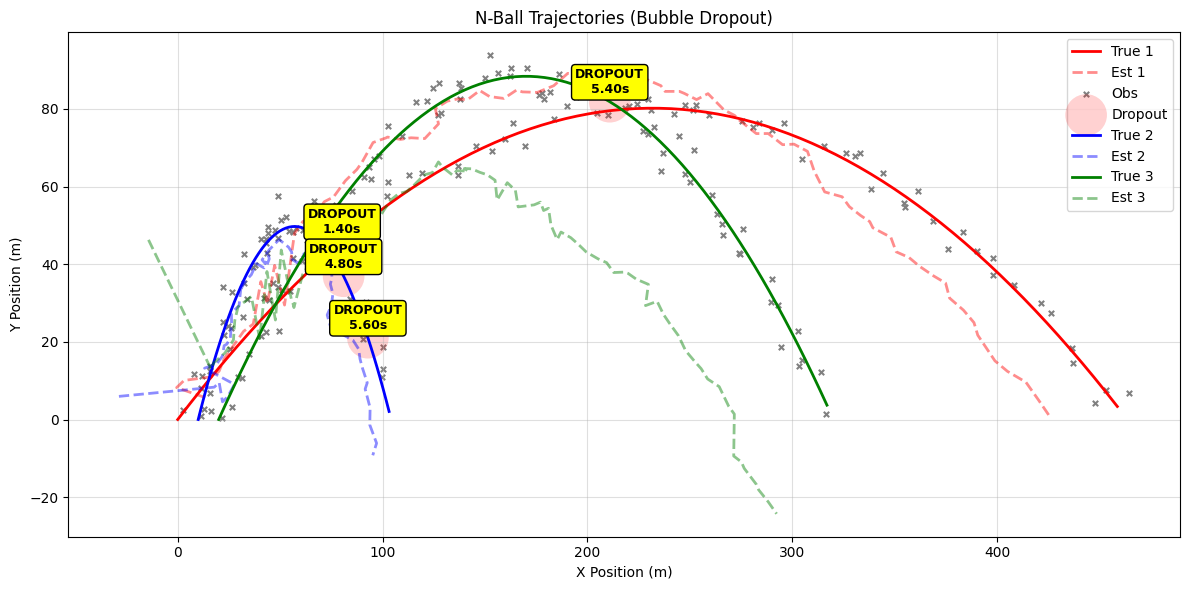

In [28]:
def assign_estimates(est: np.ndarray, true_positions: list) -> np.ndarray:
    
    assigned = np.empty_like(est)
    used = set()
    for b, tp in enumerate(true_positions):
        tp   = np.array(tp)
        best = min((j for j in range(len(est)) if j not in used),
                    key=lambda j: np.linalg.norm(est[j, :2] - tp))
        assigned[b] = est[best]
        used.add(best)
    return assigned

N_BALLS      = len(launches)

pf = NBallParticleFilter(num_particles=5000, n_balls=N_BALLS, noise_stddev=NOISE_STDDEV, area=100.0, noise=NOISE_STDDEV/2)

estimated_trajectories = {i: [] for i in range(N_BALLS)}

# Use longest sequence so no ball is cut short
n_steps = max(len(seq) for seq in obs_sequences)

_cw = 15  # width of each obs/est value cell
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'TIME STEP':^10}||" + "".join(f"{'BALL '+str(b):^{_cw*2+3}}||" for b in range(N_BALLS)))
print("=" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))
print(f"{'':10}||" + "".join(f"{'Obs.':^{_cw}} | {'Est.':^{_cw}}||" for b in range(N_BALLS)))
print("-" * (10 + 2 + (N_BALLS * (_cw * 2 + 3 + 2))))

fmt = lambda v: f"({v[0]:6.1f},{v[1]:6.1f})" if v is not None else f"{'N/A':^{_cw}}"
time_values = []
observed_balls = []
estimated_balls = []


for step_idx in range(n_steps):
        t        = next(obs_sequences[b][step_idx][0] for b in range(N_BALLS) if step_idx < len(obs_sequences[b]))
        obs_list = [obs_sequences[b][step_idx][1] if step_idx < len(obs_sequences[b]) else None for b in range(N_BALLS)]
        true_pos = [trajectories[b][min(step_idx, len(trajectories[b])-1)][1:3] for b in range(N_BALLS)]
        est      = assign_estimates(pf.step(dt=DT, observations=obs_list), true_pos)

        for b in range(N_BALLS):
            if step_idx < len(trajectories[b]):
                estimated_trajectories[b].append(est[b])
        time_values.append(t)

        observed_balls.append(sum(1 for o in obs_list if o is not None))

        estimated_balls.append(sum(1 for b in range(N_BALLS)
        if step_idx < len(trajectories[b])))
 
        print(f"t={t:5.2f}s  ||" + "".join(
            f"{fmt(obs_list[b])} | {fmt(est[b, :2] if step_idx < len(trajectories[b]) else None)}||"
            for b in range(N_BALLS)))


nBallTrajectoryPlot(
    trajectories=trajectories,
    observations=obs_sequences,
    estimates=[estimated_trajectories[i] for i in range(N_BALLS)]
).visualize()



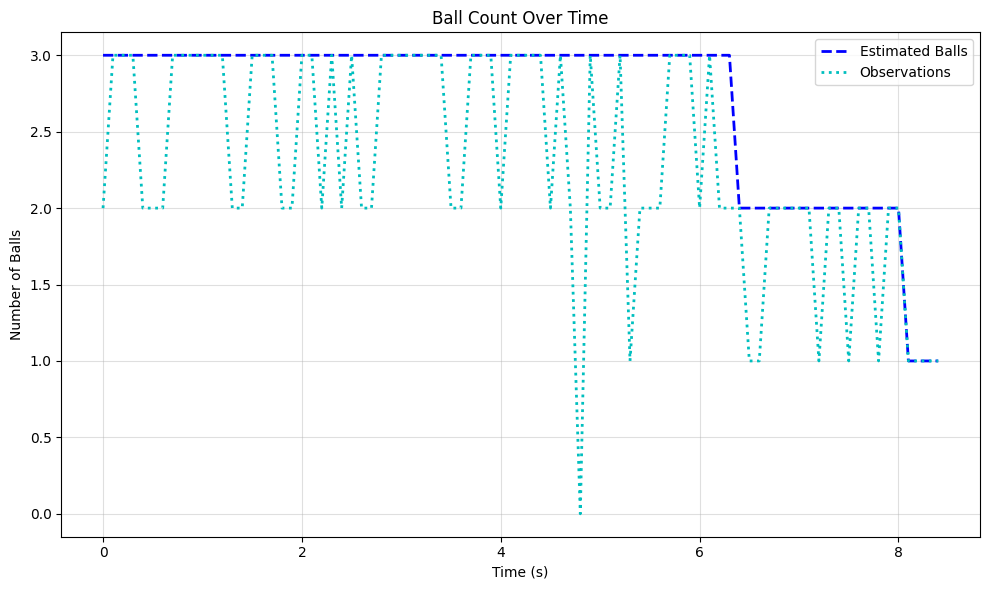

In [29]:
plot = BallCountPlot(time_values, estimated_balls, observed_balls)
plot.visualize()


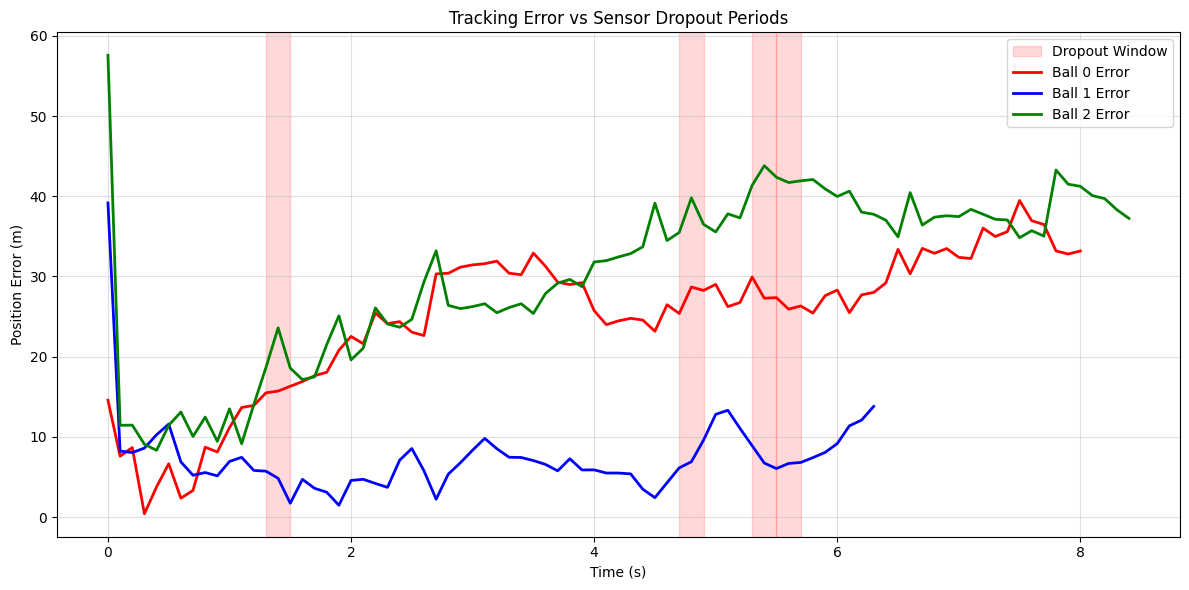

In [31]:
errors_dict = compute_tracking_errors(trajectories, estimated_trajectories)
dropout_regions = extract_dropout_regions(obs_sequences)

error_plot = TrackingErrorPlot(time_values, errors_dict, dropout_regions)
error_plot.visualize()
